In [ ]:
import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})

### Day 4

In [1]:
import gzip, time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle

def is_valid(bc):
    return (bc[4:6]=='TG'
            and bc[10:12]=='CA' 
            and bc[16:18]=='AC' 
            and bc[22:24]=='GA' 
            and bc[28:30]=='GT'
            and bc[34:36]=='AG')

def in_filtered_list(cell_bc, filtered_cell_barcodes):
    num_Ns = sum([c=='N' for c in cell_bc])
    if num_Ns > 1: return False
    elif num_Ns == 1: return np.any([cell_bc.replace('N',c) in filtered_cell_barcodes for c in 'ACTG'])
    else: return cell_bc in filtered_cell_barcodes

In [4]:
larry_prefix = 'GTTGCTAGGAGAGACCATATG'
N_READS = 10
N_UMIS = 3
N_HAMMING = 3

output_prefix = 'Larry_day-12'

sample_paths = {
    'Larry_day-12': {
        'filtered_cell_barcodes_path':
        '/mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix/barcodes.tsv.gz',
        'larry_barcode_fastq_paths':[
            '/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_1.fq.gz',
            '/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_2.fq.gz'
        ]
    }
}

In [ ]:
counts = {}

for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    filtered_cell_barcodes_set = set(filtered_cell_barcodes)

    for fastq_path in paths['larry_barcode_fastq_paths']:
        R1 = gzip.open('/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_1.fq.gz')
        R2 = gzip.open('/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_2.fq.gz')
        counter = 0
        start_time = time.time()
        while True:
            counter += 1
            if counter % 1000000 == 0: print(fastq_path+ ': Processed {} lines in {} seconds'.format(counter, time.time()-start_time))
            try:
                r1_line = R1.readline().decode('utf-8')
                r2_line = R2.readline().decode('utf-8')
            except:
                print('ERROR extracting {}'.format(fastq_path))
                break
            if r2_line == '': break
            if r2_line[0] in '@+': continue
            if larry_prefix in r2_line:
                larry_bc = r2_line.split(larry_prefix)[1][:40]
                cell_bc = r1_line[:16]+'-1'
                umi = r1_line[16:24]
                if is_valid(larry_bc) and in_filtered_list(cell_bc, filtered_cell_barcodes):
                    combo = (sample, cell_bc, umi, larry_bc)
                    if combo in counts:
                        counts[combo] += 1
                    else:
                        counts[combo] = 1

In [2]:
# Load the object from the file
with open('Larry_day4_barcode.pkl', 'rb') as file:
    counts = pickle.load(file)

In [5]:
counts

{('Larry_day-4',
  'CATGAGTTCACTACTT-1',
  'GAATGAGC',
  'CCGGTGTCAACAACGAACACCCGATAGCGTGCTTAGTCTC'): 218,
 ('Larry_day-4',
  'GACAGCCAGATTCGCT-1',
  'TAGTGTTC',
  'TCGCTGTCATCAAGTCACTTCGGAAAGCGTCTACAGTACA'): 224,
 ('Larry_day-4',
  'TGTGGCGTCAAGGCTT-1',
  'TTAAATCG',
  'TACCTGTGACCACCGTACGGTTGATACGGTAAGCAGAATG'): 144,
 ('Larry_day-4',
  'TGCATGAAGAGAGCCT-1',
  'TGGTACAT',
  'AAGCTGTCTGCAAGCCACCTCCGATTGAGTCGTCAGTGCT'): 212,
 ('Larry_day-4',
  'CTAAGTGTCGAAACAA-1',
  'ACCGGCGG',
  'ATCTTGAAGTCATGTAACCTCTGAGTGAGTACCAAGGTCG'): 358,
 ('Larry_day-4',
  'TTCCTAAAGAGCCATG-1',
  'CACACCTG',
  'GACGTGTTAACAACCCACTCACGATGCTGTCTGGAGATCC'): 124,
 ('Larry_day-4',
  'TATACCTCAAGCGGAT-1',
  'CTTCTGTA',
  'TGATTGACTACATAAAACACGGGAAATAGTTATAAGCATT'): 258,
 ('Larry_day-4',
  'CAGTGCGAGATGTAGT-1',
  'AAATTGCA',
  'CAAGTGCTTGCAGCACACCGTTGAGCTCGTAAGGAGGAGA'): 376,
 ('Larry_day-4',
  'ACTATGGTCGAACACT-1',
  'AAGACGCC',
  'TAAGTGCAGACAAGCAACGGCCGAGAACGTGTCAAGCCTG'): 234,
 ('Larry_day-4',
  'ATCGTGAGTCCGGTGT-

In [3]:
len(counts)

8756668

In [13]:
N_READS = 30
N_UMIS = 3
N_HAMMING = 3

Retaining 1739607 out of 8756668 (Sample,Cell-BC,UMI,GFP-BC) combinations


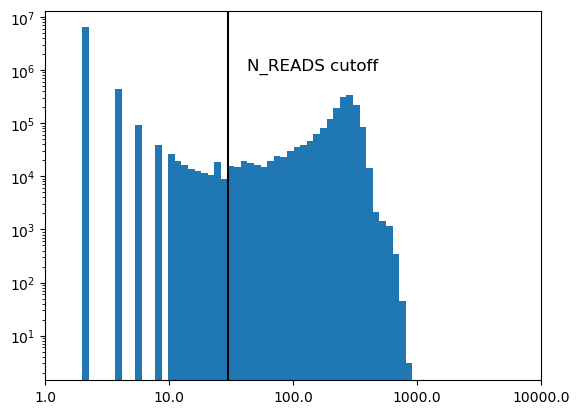

In [14]:
num_reads = [v for k,v in counts.items()]
plt.hist(np.log(num_reads)/np.log(10), bins=50)
plt.axvline(np.log(N_READS)/np.log(10),c='k')
plt.xticks(range(5),np.logspace(0,4,5))
plt.text(np.log(N_READS)/np.log(10)*1.1,10**6,'N_READS cutoff', fontsize=12)
plt.yscale('log')

counts_filtered = {k:v for k,v in counts.items() if v >= N_READS}
print('Retaining '+repr(len(counts_filtered))+ ' out of '+repr(len(counts))+' (Sample,Cell-BC,UMI,GFP-BC) combinations')

In [15]:
def hamming(bc1,bc2): return np.sum([x1 != x2 for x1,x2 in zip(bc1,bc2)])

all_gfp_bcs = sorted(set([k[3] for k in counts_filtered]))
good_gfp_bcs = []
bc_map = {}
for i,bc1 in enumerate(all_gfp_bcs):
    if i > 0 and i % 500 == 0: print('Mapped '+repr(i)+' out of '+repr(len(all_gfp_bcs))+' barcodes')
    mapped = False
    for bc2 in good_gfp_bcs:
        if hamming(bc1,bc2) <= N_HAMMING:
            mapped = True
            bc_map[bc1] = bc2
            break
    if not mapped:
        good_gfp_bcs.append(bc1)

print('\nCollapsed '+repr(len(bc_map))+' barcodes')
for bc in good_gfp_bcs: bc_map[bc] = bc

Mapped 500 out of 7889 barcodes
Mapped 1000 out of 7889 barcodes
Mapped 1500 out of 7889 barcodes
Mapped 2000 out of 7889 barcodes
Mapped 2500 out of 7889 barcodes
Mapped 3000 out of 7889 barcodes
Mapped 3500 out of 7889 barcodes
Mapped 4000 out of 7889 barcodes
Mapped 4500 out of 7889 barcodes
Mapped 5000 out of 7889 barcodes
Mapped 5500 out of 7889 barcodes
Mapped 6000 out of 7889 barcodes
Mapped 6500 out of 7889 barcodes
Mapped 7000 out of 7889 barcodes
Mapped 7500 out of 7889 barcodes

Collapsed 4228 barcodes



Final annotation has 2934 clones in 5023 cells


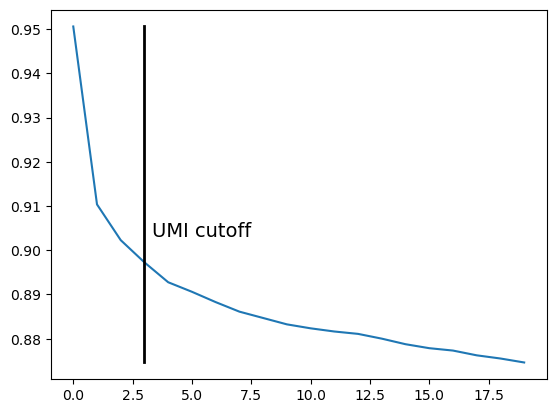

In [16]:
cell_data = {}
for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    for cell_bc in filtered_cell_barcodes:
        cell_data[(sample,cell_bc)] = {}

for sample,cell_bc,umi,larry_bc in counts_filtered.keys():
    if (sample,cell_bc) in cell_data:
        if not larry_bc in cell_data[(sample,cell_bc)]:
            cell_data[(sample,cell_bc)][larry_bc] = 0
        cell_data[(sample,cell_bc)][larry_bc] += 1

num_cells_with_barcode = np.zeros(20)
for larry_bc_counts in cell_data.values():
    if len(larry_bc_counts)>0:
        num_cells_with_barcode[:np.min([20,np.max(list(larry_bc_counts.values()))])] += 1
efficiency = num_cells_with_barcode / len(cell_data)
plt.plot(range(20),efficiency)
plt.plot([N_UMIS,N_UMIS],[np.min(efficiency),np.max(efficiency)],'-k',linewidth=2)
plt.text(N_UMIS*1.1,np.max(efficiency)*.95,'UMI cutoff',fontsize=14)

final_BCs = {}
for k,larry_bc_counts in cell_data.items():
    final_BCs[k] = '-'.join(sorted([k for k,v in larry_bc_counts.items() if v >= N_UMIS]))
print('\nFinal annotation has '+repr(len(set(final_BCs.values())))+' clones in '+repr(len([k for k,v in final_BCs.items() if len(v)>0]))+' cells')

In [17]:
output = []
for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    for cell_bc in filtered_cell_barcodes:
        output.append(sample+','+cell_bc+','+final_BCs[(sample,cell_bc)])
open(output_prefix+'.larry_d4_clones-240930.csv','w').write('\n'.join(output))

457437

### Day 12

In [1]:
import gzip, time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle

def is_valid(bc):
    return (bc[4:6]=='TG'
            and bc[10:12]=='CA' 
            and bc[16:18]=='AC' 
            and bc[22:24]=='GA' 
            and bc[28:30]=='GT'
            and bc[34:36]=='AG')

def in_filtered_list(cell_bc, filtered_cell_barcodes):
    num_Ns = sum([c=='N' for c in cell_bc])
    if num_Ns > 1: return False
    elif num_Ns == 1: return np.any([cell_bc.replace('N',c) in filtered_cell_barcodes for c in 'ACTG'])
    else: return cell_bc in filtered_cell_barcodes

In [2]:
larry_prefix = 'GTTGCTAGGAGAGACCATATG'
N_READS = 10
N_UMIS = 3
N_HAMMING = 3

output_prefix = 'Larry_day-12'

sample_paths = {
    'Larry_day-12': {
        'filtered_cell_barcodes_path':'/mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix/barcodes.tsv.gz',
        'larry_barcode_fastq_paths':[
            '/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz',
            '/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JYVHLT4_L8_{}.fq.gz', 
            '/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22KGWKLT4_L6_{}.fq.gz'
        ]
    }
}

In [3]:
counts = {}

for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    filtered_cell_barcodes_set = set(filtered_cell_barcodes)

    for fastq_path in paths['larry_barcode_fastq_paths']:
        R1 = gzip.open(fastq_path.format('R1'))
        R2 = gzip.open(fastq_path.format('R2'))
        counter = 0
        start_time = time.time()
        while True:
            counter += 1
            if counter % 1000000 == 0: print(fastq_path+ ': Processed {} lines in {} seconds'.format(counter, time.time()-start_time))
            try:
                r1_line = R1.readline().decode('utf-8')
                r2_line = R2.readline().decode('utf-8')
            except:
                print('ERROR extracting {}'.format(fastq_path))
                break
            if r2_line == '': break
            if r2_line[0] in '@+': continue
            if larry_prefix in r2_line:
                larry_bc = r2_line.split(larry_prefix)[1][:40]
                cell_bc = r1_line[:16]+'-1'
                umi = r1_line[16:24]
                if is_valid(larry_bc) and in_filtered_list(cell_bc, filtered_cell_barcodes):
                    combo = (sample, cell_bc, umi, larry_bc)
                    if combo in counts:
                        counts[combo] += 1
                    else:
                        counts[combo] = 1

/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 1000000 lines in 18.16242742538452 seconds
/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 2000000 lines in 36.32347059249878 seconds
/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 3000000 lines in 54.53359532356262 seconds
/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 4000000 lines in 73.01703310012817 seconds
/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 5000000 lines in 91.34905076026917 seconds
/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/raw_data/Larry4_FKDL240216857-1A_22JGC2LT4_L6_{}.fq.gz: Processed 6000000 lines in 109.73215389251709 seconds
/mnt/yiming/nfs_share/larry/barcode-pre

KeyboardInterrupt: 

In [3]:
# Load the object from the file
with open('/mnt/yiming/nfs_share/larry/barcode-preprocess-d12/Larry_day12_barcode_v3.pkl', 'rb') as file:
    counts = pickle.load(file)

In [4]:
counts

{('Larry_day-12',
  'TNGCATTTCTCATTAC-1',
  'GCAACTTT',
  'GCGCTGCCCGCAAGACACACGCGACCCAGTACCAAGTAAA'): 1,
 ('Larry_day-12',
  'ANGGTTAGTAAGGCCA-1',
  'ATGAGTAA',
  'CATGTGGCACCATTCCACAAGCGATGTAGTATCCAGCTTT'): 1,
 ('Larry_day-12',
  'GNCATTCCAACCACAT-1',
  'CGTTTGCA',
  'GAACTGAGAACAACACACTATAGAACGTGTAACAAGAGAG'): 1,
 ('Larry_day-12',
  'TNCGCTCAGGATATGT-1',
  'TTCTAGGG',
  'CCCCTGCCAACATCCCACAAGCGAACGAGTAAAAAGGTTT'): 1,
 ('Larry_day-12',
  'GNAGTAACATGTCGTA-1',
  'CCACTCGT',
  'AATGTGGCACCATTCAACGAGCGATGTAGTATCCAGACTT'): 1,
 ('Larry_day-12',
  'CNAACTTGTTTCACAG-1',
  'AAAACCCT',
  'AGAATGACCCCACGGAACGTGCGAGTAAGTTGATAGGGCT'): 1,
 ('Larry_day-12',
  'GNTGAGGGTCTACAAC-1',
  'AGCCAAGC',
  'ATCGTGATGTCACCAAACACACGACGTAGTAAAAAGATGC'): 1,
 ('Larry_day-12',
  'TNGAGTGTCGTGGGAA-1',
  'ACCTTGTA',
  'CGCCTGAATTCAGCGAACTGCCGAAAGAGTTAACAGTCAG'): 1,
 ('Larry_day-12',
  'GNTCCCTGTAATGCTC-1',
  'CGGTTGCT',
  'TTACTGTGATCACTTGACGGGCGAGCCGGTCAACAGCGGA'): 1,
 ('Larry_day-12',
  'CNGGTCTAGATACTGA-1',
  'C

In [5]:
len(counts)

19945383

In [14]:
N_READS = 10
N_UMIS = 3
N_HAMMING = 3

Retaining 474831 out of 19945383 (Sample,Cell-BC,UMI,GFP-BC) combinations


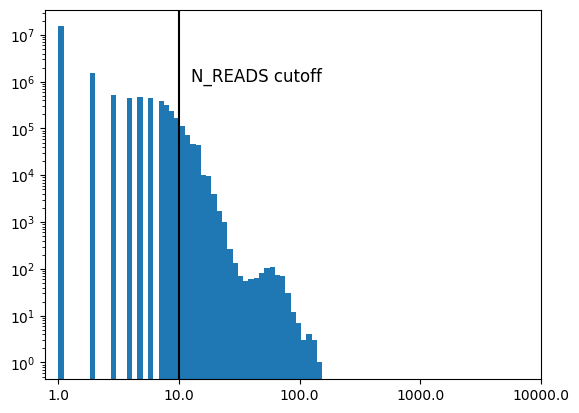

In [15]:
num_reads = [v for k,v in counts.items()]
plt.hist(np.log(num_reads)/np.log(10), bins=50)
plt.axvline(np.log(N_READS)/np.log(10),c='k')
plt.xticks(range(5),np.logspace(0,4,5))
plt.text(np.log(N_READS)/np.log(10)*1.1,10**6,'N_READS cutoff', fontsize=12)
plt.yscale('log')

counts_filtered = {k:v for k,v in counts.items() if v >= N_READS}
print('Retaining '+repr(len(counts_filtered))+ ' out of '+repr(len(counts))+' (Sample,Cell-BC,UMI,GFP-BC) combinations')

In [16]:
def hamming(bc1,bc2): return np.sum([x1 != x2 for x1,x2 in zip(bc1,bc2)])

all_gfp_bcs = sorted(set([k[3] for k in counts_filtered]))
good_gfp_bcs = []
bc_map = {}
for i,bc1 in enumerate(all_gfp_bcs):
    if i > 0 and i % 500 == 0: print('Mapped '+repr(i)+' out of '+repr(len(all_gfp_bcs))+' barcodes')
    mapped = False
    for bc2 in good_gfp_bcs:
        if hamming(bc1,bc2) <= N_HAMMING:
            mapped = True
            bc_map[bc1] = bc2
            break
    if not mapped:
        good_gfp_bcs.append(bc1)

print('\nCollapsed '+repr(len(bc_map))+' barcodes')
for bc in good_gfp_bcs: bc_map[bc] = bc

Mapped 500 out of 2280 barcodes
Mapped 1000 out of 2280 barcodes
Mapped 1500 out of 2280 barcodes
Mapped 2000 out of 2280 barcodes

Collapsed 449 barcodes



Final annotation has 2743 clones in 10375 cells


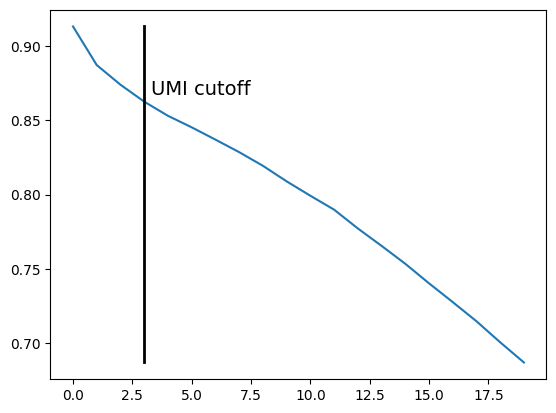

In [17]:
cell_data = {}
for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    for cell_bc in filtered_cell_barcodes:
        cell_data[(sample,cell_bc)] = {}

for sample,cell_bc,umi,larry_bc in counts_filtered.keys():
    if (sample,cell_bc) in cell_data:
        if not larry_bc in cell_data[(sample,cell_bc)]:
            cell_data[(sample,cell_bc)][larry_bc] = 0
        cell_data[(sample,cell_bc)][larry_bc] += 1

num_cells_with_barcode = np.zeros(20)
for larry_bc_counts in cell_data.values():
    if len(larry_bc_counts)>0:
        num_cells_with_barcode[:np.min([20,np.max(list(larry_bc_counts.values()))])] += 1
efficiency = num_cells_with_barcode / len(cell_data)
plt.plot(range(20),efficiency)
plt.plot([N_UMIS,N_UMIS],[np.min(efficiency),np.max(efficiency)],'-k',linewidth=2)
plt.text(N_UMIS*1.1,np.max(efficiency)*.95,'UMI cutoff',fontsize=14)

final_BCs = {}
for k,larry_bc_counts in cell_data.items():
    final_BCs[k] = '-'.join(sorted([k for k,v in larry_bc_counts.items() if v >= N_UMIS]))
print('\nFinal annotation has '+repr(len(set(final_BCs.values())))+' clones in '+repr(len([k for k,v in final_BCs.items() if len(v)>0]))+' cells')

In [18]:
output = []
for sample,paths in sample_paths.items():
    filtered_cell_barcodes = gzip.open(paths['filtered_cell_barcodes_path']).read().decode('utf-8').split('\n')
    for cell_bc in filtered_cell_barcodes:
        output.append(sample+','+cell_bc+','+final_BCs[(sample,cell_bc)])
open(output_prefix+'-250123.csv','w').write('\n'.join(output))

906666